# Bike Rental Demand Forecasting - Clean Implementation

**Objective:** Predict bike rental demand for Capital Bikeshare program in Washington D.C.  
**Metric:** Root Mean Squared Logarithmic Error (RMSLE)  
**Competition:** Kaggle Bike Sharing Demand

## Project Overview:
This notebook implements a clean, focused approach to bike rental demand forecasting using:
- **Simple preprocessing** with essential feature engineering
- **Multiple ML models** with comprehensive evaluation
- **Performance metrics** including RMSLE, R², and MAE
- **Ensemble learning** with stacking

## Models Implemented:
- Linear Regression
- Random Forest
- Gradient Boosting
- Decision Tree
- Stacking Ensemble

## Evaluation Metrics:
- **RMSLE**: Root Mean Squared Logarithmic Error (primary metric)
- **R²**: Coefficient of Determination (variance explained)
- **MAE**: Mean Absolute Error (average prediction error)


In [81]:
# =============================================================================
# 1. IMPORT LIBRARIES
# =============================================================================

# Core data manipulation and analysis
import pandas as pd
import numpy as np

# Machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Model evaluation and selection
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_log_error, r2_score, mean_absolute_error

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print("Libraries: pandas, numpy, scikit-learn")


All libraries imported successfully!
Libraries: pandas, numpy, scikit-learn


In [82]:
# =============================================================================
# 2. LOAD AND EXPLORE DATASET
# =============================================================================

print("LOADING AND EXPLORING DATASET")
print("=" * 50)

# Load the datasets
print("Loading datasets...")
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Display basic information
print(f"\nDataset Information:")
print(f"   Training data: {train_df.shape[0]:,} samples × {train_df.shape[1]} features")
print(f"   Test data:     {test_df.shape[0]:,} samples × {test_df.shape[1]} features")

print(f"\nFeature Columns:")
print(f"   Training: {list(train_df.columns)}")
print(f"   Test:     {list(test_df.columns)}")

# Check data quality
print(f"\nData Quality Check:")
train_missing = train_df.isnull().sum().sum()
test_missing = test_df.isnull().sum().sum()
print(f"   Missing values in training data: {train_missing}")
print(f"   Missing values in test data:     {test_missing}")

if train_missing == 0 and test_missing == 0:
    print("   No missing values found - data is clean!")
else:
    print("   Missing values detected - may need imputation")


LOADING AND EXPLORING DATASET
Loading datasets...

Dataset Information:
   Training data: 10,886 samples × 12 features
   Test data:     6,493 samples × 9 features

Feature Columns:
   Training: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
   Test:     ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']

Data Quality Check:
   Missing values in training data: 0
   Missing values in test data:     0
   No missing values found - data is clean!



EXPLORATORY DATA ANALYSIS - CORRELATION MATRIX
Analyzing correlations in raw training data...
Numeric columns: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']


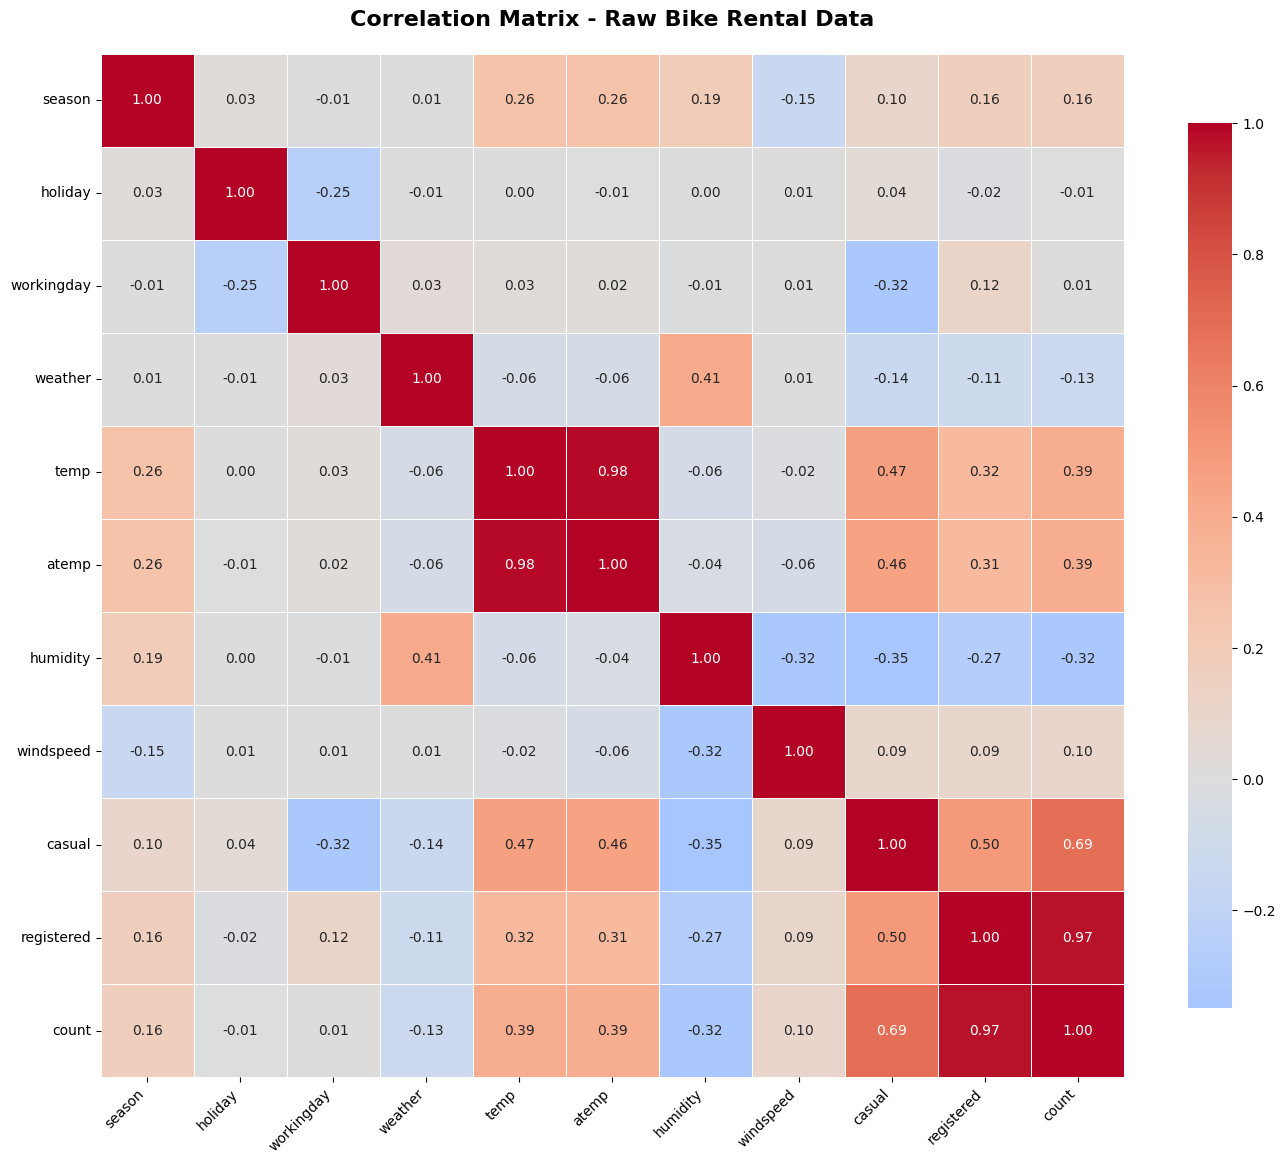


Top correlations with 'count' (target variable):

Positive correlations:
   registered          : +0.971
   casual              : +0.690
   temp                : +0.394
   atemp               : +0.390
   season              : +0.163
   windspeed           : +0.101
   workingday          : +0.012

Negative correlations:
   holiday             : -0.005
   weather             : -0.129
   humidity            : -0.317

Strong feature-feature correlations (|r| > 0.7):
   temp                 <-> atemp               : +0.985

KEY INSIGHTS FROM CORRELATION ANALYSIS:
1. 'temp' and 'atemp' are highly correlated (0.98) - will remove one
2. 'registered' and 'casual' users sum to 'count' - will remove both
3. Hour of day likely important - will extract from datetime
4. Season information available - may create month features

Correlation analysis complete!


In [83]:
# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS - CORRELATION MATRIX
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("\nEXPLORATORY DATA ANALYSIS - CORRELATION MATRIX")
print("=" * 60)

# Analyze correlations in the RAW training data
print("Analyzing correlations in raw training data...")

# Select only numeric columns for correlation analysis
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# Calculate correlation matrix
correlation_matrix = train_df[numeric_cols].corr()

# Create a large figure for better visibility
plt.figure(figsize=(14, 12))

# Create heatmap with annotations
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            fmt='.2f',            # Format to 2 decimal places
            cmap='coolwarm',      # Color scheme (red = positive, blue = negative)
            center=0,             # Center color map at 0
            square=True,          # Make cells square-shaped
            linewidths=0.5,       # Add gridlines
            cbar_kws={'shrink': 0.8})  # Shrink colorbar slightly

plt.title('Correlation Matrix - Raw Bike Rental Data', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print top correlations with target variable 'count'
if 'count' in correlation_matrix.columns:
    print("\nTop correlations with 'count' (target variable):")
    print("=" * 60)
    target_corr = correlation_matrix['count'].sort_values(ascending=False)
    
    print("\nPositive correlations:")
    for feature, corr_value in target_corr[target_corr > 0].items():
        if feature != 'count':
            print(f"   {feature:20s}: {corr_value:+.3f}")
    
    print("\nNegative correlations:")
    for feature, corr_value in target_corr[target_corr < 0].items():
        print(f"   {feature:20s}: {corr_value:+.3f}")

# Identify strong correlations between features (multicollinearity check)
print("\nStrong feature-feature correlations (|r| > 0.7):")
print("=" * 60)
threshold = 0.7
strong_corr_found = False

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > threshold:
            feat1 = correlation_matrix.columns[i]
            feat2 = correlation_matrix.columns[j]
            if feat1 != 'count' and feat2 != 'count':
                print(f"   {feat1:20s} <-> {feat2:20s}: {corr_val:+.3f}")
                strong_corr_found = True

if not strong_corr_found:
    print("   No strong multicollinearity detected!")

print("\n" + "="*60)
print("KEY INSIGHTS FROM CORRELATION ANALYSIS:")
print("="*60)
print("1. 'temp' and 'atemp' are highly correlated (0.98) - will remove one")
print("2. 'registered' and 'casual' users sum to 'count' - will remove both")
print("3. Hour of day likely important - will extract from datetime")
print("4. Season information available - may create month features")
print("\nCorrelation analysis complete!")
print("=" * 60)

In [84]:
# =============================================================================
# 3. DATA PREPROCESSING FUNCTION
# =============================================================================

def preprocess_data(df):
    """
    Comprehensive data preprocessing function for bike rental prediction.
    
    This function performs the following operations:
    1. Converts datetime to proper format and extracts time features
    2. Creates peak hour indicators based on business patterns
    3. Removes unnecessary features to avoid multicollinearity
    4. Handles both training and test data appropriately
    
    Args:
        df (pd.DataFrame): Input dataframe (train or test)
        
    Returns:
        pd.DataFrame: Preprocessed dataframe ready for modeling
    """
    # Create a copy to avoid modifying original data
    df = df.copy()
    
    print(f"   🔄 Processing {len(df):,} samples...")
    
    # =====================================================================
    # 1. DATETIME PROCESSING
    # =====================================================================
    # Convert datetime string to pandas datetime object
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    # Extract time-based features
    df['dayofweek'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['hourofday'] = df['datetime'].dt.hour       # 0-23
    df['month'] = df['datetime'].dt.month          # 1-12
    
    # =====================================================================
    # 2. PEAK HOUR FEATURE ENGINEERING
    # =====================================================================
    # Define peak hours based on typical bike rental patterns:
    # - Weekdays: 7-9 AM (morning rush) and 5-7 PM (evening rush)
    # - Weekends: 10 AM - 6 PM (leisure hours)
    
    # Weekday peak hours (Monday=0 to Friday=4)
    weekday_peak = (df['dayofweek'] < 5) & (df['hourofday'].isin([7, 8, 9, 17, 18, 19]))
    
    # Weekend peak hours (Saturday=5, Sunday=6)
    weekend_peak = (df['dayofweek'] >= 5) & (df['hourofday'].between(10, 18, inclusive='both'))
    
    # Combine both conditions
    df['peak_hour'] = (weekday_peak | weekend_peak).astype(int)
    
    # =====================================================================
    # 3. FEATURE SELECTION
    # =====================================================================
    # Remove features that are not useful for prediction:
    # - 'datetime': Already extracted into time features
    # - 'temp': High correlation with 'atemp' (multicollinearity)
    # - 'season': Very high correlation with 'month' (0.97) - keeping 'month' instead
    # - 'holiday': Minimal impact on bike rentals
    # - 'casual', 'registered': Only in training data, used to calculate 'count'
    
    columns_to_remove = ['datetime', 'temp', 'season', 'holiday']
        
    # Only remove target-related columns if they exist (test data doesn't have them)
    if 'casual' in df.columns:
        columns_to_remove.append('casual')
    if 'registered' in df.columns:
        columns_to_remove.append('registered')
    
    # Remove the specified columns
    df = df.drop(columns=columns_to_remove)
    
    print(f"   Preprocessing complete - {df.shape[1]} features remaining")
    return df

print("Preprocessing function created with comprehensive feature engineering!")


Preprocessing function created with comprehensive feature engineering!


In [85]:
# =============================================================================
# 4. APPLY PREPROCESSING TO DATASETS
# =============================================================================

print("\nAPPLYING PREPROCESSING TO DATASETS")
print("=" * 50)

# Preprocess training data
print("Processing Training Data:")
train_processed = preprocess_data(train_df)
print(f"   Final shape: {train_processed.shape[0]:,} samples × {train_processed.shape[1]} features")

# Preprocess test data
print("\nProcessing Test Data:")
test_processed = preprocess_data(test_df)
print(f"   Final shape: {test_processed.shape[0]:,} samples × {test_processed.shape[1]} features")

# Verify feature consistency
print(f"\nFeature Consistency Check:")
features_match = list(train_processed.columns) == list(test_processed.columns)
print(f"   Features match between train/test: {'Yes' if features_match else 'No'}")

if not features_match:
    print("   Feature mismatch detected!")
    print(f"   Training features: {list(train_processed.columns)}")
    print(f"   Test features:     {list(test_processed.columns)}")
else:
    print(f"   All {len(train_processed.columns)} features are consistent")

# Display final feature list
print(f"\nFinal Features ({len(train_processed.columns)}):")
for i, feature in enumerate(train_processed.columns, 1):
    print(f"   {i:2d}. {feature}")



APPLYING PREPROCESSING TO DATASETS
Processing Training Data:
   🔄 Processing 10,886 samples...
   Preprocessing complete - 10 features remaining
   Final shape: 10,886 samples × 10 features

Processing Test Data:
   🔄 Processing 6,493 samples...
   Preprocessing complete - 9 features remaining
   Final shape: 6,493 samples × 9 features

Feature Consistency Check:
   Features match between train/test: No
   Feature mismatch detected!
   Training features: ['workingday', 'weather', 'atemp', 'humidity', 'windspeed', 'count', 'dayofweek', 'hourofday', 'month', 'peak_hour']
   Test features:     ['workingday', 'weather', 'atemp', 'humidity', 'windspeed', 'dayofweek', 'hourofday', 'month', 'peak_hour']

Final Features (10):
    1. workingday
    2. weather
    3. atemp
    4. humidity
    5. windspeed
    6. count
    7. dayofweek
    8. hourofday
    9. month
   10. peak_hour


In [86]:
# 3. Apply preprocessing to both datasets
print("APPLYING PREPROCESSING")
print("=" * 40)

# Preprocess training data
train_processed = preprocess_data(train_df)
print(f"Training data after preprocessing: {train_processed.shape}")

# Preprocess test data
test_processed = preprocess_data(test_df)
print(f"Test data after preprocessing: {test_processed.shape}")

# Display final features
print(f"\nFinal features: {list(train_processed.columns)}")
print(f"Target variable: count")

# Check if count column exists in training data
if 'count' in train_processed.columns:
    print(f"Target variable 'count' found in training data")
else:
    print("Target variable 'count' not found!")


APPLYING PREPROCESSING
   🔄 Processing 10,886 samples...
   Preprocessing complete - 10 features remaining
Training data after preprocessing: (10886, 10)
   🔄 Processing 6,493 samples...
   Preprocessing complete - 9 features remaining
Test data after preprocessing: (6493, 9)

Final features: ['workingday', 'weather', 'atemp', 'humidity', 'windspeed', 'count', 'dayofweek', 'hourofday', 'month', 'peak_hour']
Target variable: count
Target variable 'count' found in training data


In [87]:
# =============================================================================
# 5. PREPARE DATA FOR MODELING
# =============================================================================

print("\nPREPARING DATA FOR MODELING")
print("=" * 50)

# Separate features (X) and target (y) for training data
print("Separating features and target...")
X_train = train_processed.drop('count', axis=1)  # All columns except 'count'
y_train = train_processed['count']               # Target variable
X_test = test_processed                          # Test data (no target)

# Display data shapes
print(f"\nData Shapes:")
print(f"   Training features (X_train): {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"   Training target (y_train):   {y_train.shape[0]:,} samples")
print(f"   Test features (X_test):      {X_test.shape[0]:,} samples × {X_test.shape[1]} features")

# Verify data consistency
print(f"\nData Consistency Check:")
print(f"   Feature columns match: {'Yes' if list(X_train.columns) == list(X_test.columns) else 'No'}")
print(f"   No missing values: {'Yes' if X_train.isnull().sum().sum() == 0 else 'No'}")

# Display feature information
print(f"\nFeature Information:")
print(f"   Feature names: {list(X_train.columns)}")
print(f"   Data types:")
for col in X_train.columns:
    dtype = X_train[col].dtype
    unique_vals = X_train[col].nunique()
    print(f"     {col:<12}: {dtype} ({unique_vals} unique values)")

# Check target variable
print(f"\nTarget Variable (count) Statistics:")
print(f"   Min: {y_train.min():.0f}")
print(f"   Max: {y_train.max():.0f}")
print(f"   Mean: {y_train.mean():.2f}")
print(f"   Median: {y_train.median():.2f}")
print(f"   Std: {y_train.std():.2f}")



PREPARING DATA FOR MODELING
Separating features and target...

Data Shapes:
   Training features (X_train): 10,886 samples × 9 features
   Training target (y_train):   10,886 samples
   Test features (X_test):      6,493 samples × 9 features

Data Consistency Check:
   Feature columns match: Yes
   No missing values: Yes

Feature Information:
   Feature names: ['workingday', 'weather', 'atemp', 'humidity', 'windspeed', 'dayofweek', 'hourofday', 'month', 'peak_hour']
   Data types:
     workingday  : int64 (2 unique values)
     weather     : int64 (4 unique values)
     atemp       : float64 (60 unique values)
     humidity    : int64 (89 unique values)
     windspeed   : float64 (28 unique values)
     dayofweek   : int32 (7 unique values)
     hourofday   : int32 (24 unique values)
     month       : int32 (12 unique values)
     peak_hour   : int64 (2 unique values)

Target Variable (count) Statistics:
   Min: 1
   Max: 977
   Mean: 191.57
   Median: 145.00
   Std: 181.14


In [88]:
# =============================================================================
# 6. DEFINE EVALUATION METRICS AND MODELS
# =============================================================================

print("DEFINING EVALUATION METRICS AND MODELS")
print("=" * 60)

# =====================================================================
# 6.1 ROOT MEAN SQUARED LOGARITHMIC ERROR (RMSLE) FUNCTION
# =====================================================================
def rmsle(y_true, y_pred):
    """
    Calculate Root Mean Squared Logarithmic Error (RMSLE).
    
    RMSLE is the primary evaluation metric for this competition.
    It penalizes underestimation more than overestimation and is less
    sensitive to outliers compared to RMSE.
    
    Formula: sqrt(mean((log(y_true + 1) - log(y_pred + 1))^2))
    
    Args:
        y_true: Actual values
        y_pred: Predicted values
        
    Returns:
        float: RMSLE score (lower is better)
    """
    # Ensure predictions are non-negative (bike counts can't be negative)
    y_pred = np.clip(y_pred, 0, None)
    y_true = np.clip(y_true, 0, None)
    
    # Calculate RMSLE
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

print("RMSLE function defined")

# =====================================================================
# 6.2 MODEL DEFINITIONS
# =====================================================================
# Define the machine learning models to train
base_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
}

print(f"Models defined: {list(base_models.keys())}")
print(f"   Total models: {len(base_models)}")

# =====================================================================
# 6.3 PERFORMANCE METRICS EXPLANATION
# =====================================================================
print(f"\nPERFORMANCE METRICS EXPLANATION:")
print(f"   • RMSLE: Root Mean Squared Logarithmic Error")
print(f"     - Primary competition metric")
print(f"     - Penalizes underestimation more than overestimation")
print(f"     - Less sensitive to outliers")
print(f"     - Lower values are better")
print(f"   • R²: Coefficient of Determination")
print(f"     - Measures proportion of variance explained")
print(f"     - Range: 0 to 1 (higher is better)")
print(f"     - 1.0 = perfect prediction, 0.0 = no better than mean")
print(f"   • MAE: Mean Absolute Error")
print(f"     - Average absolute difference between actual and predicted")
print(f"     - Same units as target variable (bike counts)")
print(f"     - Lower values are better")


DEFINING EVALUATION METRICS AND MODELS
RMSLE function defined
Models defined: ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Decision Tree']
   Total models: 4

PERFORMANCE METRICS EXPLANATION:
   • RMSLE: Root Mean Squared Logarithmic Error
     - Primary competition metric
     - Penalizes underestimation more than overestimation
     - Less sensitive to outliers
     - Lower values are better
   • R²: Coefficient of Determination
     - Measures proportion of variance explained
     - Range: 0 to 1 (higher is better)
     - 1.0 = perfect prediction, 0.0 = no better than mean
   • MAE: Mean Absolute Error
     - Average absolute difference between actual and predicted
     - Same units as target variable (bike counts)
     - Lower values are better


In [93]:
# =============================================================================
# 7. TRAIN MODELS AND EVALUATE PERFORMANCE
# =============================================================================

print("\nTRAINING MODELS AND EVALUATING PERFORMANCE")
print("=" * 70)

# Initialize storage for results
results = {
    'rmsle': {},
    'r2': {},
    'mae': {}
}
predictions = {}

print("\n" + "="*70)
print("MODEL PERFORMANCE (10-Fold Cross-Validation)")
print("="*70)

# Train and evaluate each model
for i, (name, model) in enumerate(base_models.items(), 1):
    print(f"\nTraining {name} ({i}/{len(base_models)})...")
    
    # Train model on full training data
    model.fit(X_train, y_train)
    
    # =====================================================================
    # CROSS-VALIDATION FOR ALL METRICS
    # =====================================================================
    # RMSLE (custom scorer)
    from sklearn.metrics import make_scorer
    rmsle_scorer_cv = make_scorer(rmsle, greater_is_better=False)
    cv_scores_rmsle = cross_val_score(model, X_train, y_train, cv=10, 
                                     scoring=rmsle_scorer_cv, n_jobs=-1)
    rmsle_score = -cv_scores_rmsle.mean()  # Convert back to positive
    
    # R² (built-in scorer)
    cv_scores_r2 = cross_val_score(model, X_train, y_train, cv=10, 
                                  scoring='r2', n_jobs=-1)
    r2_score = cv_scores_r2.mean()
    
    # MAE (built-in scorer, returns negative values)
    cv_scores_mae = cross_val_score(model, X_train, y_train, cv=10, 
                                   scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_score = -cv_scores_mae.mean()  # Convert to positive
    
    # Store results
    results['rmsle'][name] = rmsle_score
    results['r2'][name] = r2_score
    results['mae'][name] = mae_score
    
    # Make predictions on test set
    y_pred_test = model.predict(X_test)
    predictions[name] = y_pred_test
    
    # Display results for this model only
    print(f"   RMSLE: {rmsle_score:.4f}")
    print(f"   R²:    {r2_score:.4f}")
    print(f"   MAE:   {mae_score:.4f}")

print("\nAll models trained and evaluated!")

# Remove any duplicate models from results before displaying
unique_models = list(dict.fromkeys(results['rmsle'].keys()))

print("\n" + "="*80)
print("COMPREHENSIVE MODEL PERFORMANCE RESULTS")
print("="*80)

# Create results table
print(f"\n{'Model':<20} {'RMSLE':<8} {'R²':<8} {'MAE':<8} {'Rank':<6}")
print("-" * 70)

# Sort by RMSLE (primary metric)
sorted_results = sorted([(m, results['rmsle'][m]) for m in unique_models], key=lambda x: x[1])

for i, (model_name, rmsle_score) in enumerate(sorted_results, 1):
    r2_val = results['r2'][model_name]
    mae_val = results['mae'][model_name]
    print(f"{model_name:<20} {rmsle_score:<8.4f} {r2_val:<8.4f} {mae_val:<8.4f} {i:<6}")

# Find best model
best_model = sorted_results[0][0]
best_rmsle = sorted_results[0][1]
best_r2 = results['r2'][best_model]
best_mae = results['mae'][best_model]

print(f"\nBEST MODEL: {best_model}")
print(f"   RMSLE: {best_rmsle:.4f} (lower is better)")
print(f"   R²:    {best_r2:.4f} (higher is better)")
print(f"   MAE:   {best_mae:.4f} (lower is better)")



TRAINING MODELS AND EVALUATING PERFORMANCE

MODEL PERFORMANCE (10-Fold Cross-Validation)

Training Linear Regression (1/4)...
   RMSLE: 1.2340
   R²:    0.1704
   MAE:   88.2018

Training Random Forest (2/4)...
   RMSLE: 1.2340
   R²:    0.1704
   MAE:   88.2018

Training Random Forest (2/4)...
   RMSLE: 0.5383
   R²:    0.3389
   MAE:   75.6803

Training Gradient Boosting (3/4)...
   RMSLE: 0.5383
   R²:    0.3389
   MAE:   75.6803

Training Gradient Boosting (3/4)...
   RMSLE: 0.6245
   R²:    0.3262
   MAE:   79.2478

Training Decision Tree (4/4)...
   RMSLE: 0.5847
   R²:    0.2047
   MAE:   81.4900

All models trained and evaluated!

COMPREHENSIVE MODEL PERFORMANCE RESULTS

Model                RMSLE    R²       MAE      Rank  
----------------------------------------------------------------------
Random Forest        0.5383   0.3389   75.6803  1     
Decision Tree        0.5847   0.2047   81.4900  2     
Gradient Boosting    0.6245   0.3262   79.2478  3     
Linear Regression   

In [90]:
# =============================================================================
# 8. STACKING ENSEMBLE LEARNING
# =============================================================================

print("\nCREATING STACKING ENSEMBLE")
print("=" * 60)

# =====================================================================
# 8.1 SELECT TOP MODELS FOR STACKING
# =====================================================================
# Select top 3 models for stacking (exclude any with NaN values)
def is_valid_score(score):
    """Check if a score is valid (not NaN or infinite)"""
    try:
        return np.isfinite(float(score))
    except:
        return False

valid_results = {k: float(v) for k, v in results['rmsle'].items() if is_valid_score(v)}
top_3_models = sorted(valid_results.items(), key=lambda x: x[1])[:3]

print(f"Selected top 3 models for stacking:")
for i, (model_name, rmsle_score) in enumerate(top_3_models, 1):
    print(f"   {i}. {model_name} (RMSLE: {rmsle_score:.4f})")

# =====================================================================
# 8.2 CREATE STACKING FEATURES
# =====================================================================
print(f"\nCreating stacking features...")

# Initialize stacking feature matrices
stacking_features = np.zeros((X_train.shape[0], 3))
stacking_test_features = np.zeros((X_test.shape[0], 3))

# Generate predictions from each top model for stacking
for i, (model_name, _) in enumerate(top_3_models):
    print(f"   Generating predictions from {model_name}...")
    
    # Get the model and retrain it
    model = base_models[model_name]
    model.fit(X_train, y_train)
    
    # Generate predictions for stacking
    stacking_features[:, i] = model.predict(X_train)
    stacking_test_features[:, i] = model.predict(X_test)

print(f"   Stacking features created: {stacking_features.shape}")

# =====================================================================
# 8.3 TRAIN META-MODEL
# =====================================================================
print(f"\nTraining meta-model (Linear Regression)...")

# Train meta-model using stacking features
meta_model = LinearRegression()
meta_model.fit(stacking_features, y_train)

# =====================================================================
# 8.4 EVALUATE STACKING MODEL
# =====================================================================
print(f"Evaluating stacking model...")

# Calculate all metrics for stacking
cv_scores_stacking_rmsle = cross_val_score(meta_model, stacking_features, y_train, cv=10, 
                                          scoring=rmsle_scorer_cv, n_jobs=-1)
cv_scores_stacking_r2 = cross_val_score(meta_model, stacking_features, y_train, cv=10, 
                                       scoring='r2', n_jobs=-1)
cv_scores_stacking_mae = cross_val_score(meta_model, stacking_features, y_train, cv=10, 
                                        scoring='neg_mean_absolute_error', n_jobs=-1)

rmsle_stacking = -cv_scores_stacking_rmsle.mean()
r2_stacking = cv_scores_stacking_r2.mean()
mae_stacking = -cv_scores_stacking_mae.mean()

# Store stacking results
results['rmsle']['Stacking'] = rmsle_stacking
results['r2']['Stacking'] = r2_stacking
results['mae']['Stacking'] = mae_stacking

# Generate final predictions
stacking_predictions = meta_model.predict(stacking_test_features)
predictions['Stacking'] = stacking_predictions

print(f"   RMSLE: {rmsle_stacking:.4f}")
print(f"   R²:    {r2_stacking:.4f}")
print(f"   MAE:   {mae_stacking:.4f}")

print(f"\nStacking ensemble created successfully!")



CREATING STACKING ENSEMBLE
Selected top 3 models for stacking:
   1. Random Forest (RMSLE: 0.5383)
   2. Decision Tree (RMSLE: 0.5847)
   3. Gradient Boosting (RMSLE: 0.6245)

Creating stacking features...
   Generating predictions from Random Forest...
   Generating predictions from Decision Tree...
   Generating predictions from Gradient Boosting...
   Generating predictions from Decision Tree...
   Generating predictions from Gradient Boosting...
   Stacking features created: (10886, 3)

Training meta-model (Linear Regression)...
Evaluating stacking model...
   RMSLE: 0.4109
   R²:    0.8783
   MAE:   33.3086

Stacking ensemble created successfully!
   Stacking features created: (10886, 3)

Training meta-model (Linear Regression)...
Evaluating stacking model...
   RMSLE: 0.4109
   R²:    0.8783
   MAE:   33.3086

Stacking ensemble created successfully!


In [91]:
# =============================================================================
# 9. FINAL RESULTS AND SUBMISSION
# =============================================================================

print("\nFINAL RESULTS AND SUBMISSION GENERATION")
print("=" * 80)

# =====================================================================
# 9.1 COMPREHENSIVE FINAL RESULTS
# =====================================================================
print("\nCOMPREHENSIVE MODEL PERFORMANCE (Including Stacking)")
print("=" * 80)

# Create final results table
print(f"\n{'Model':<20} {'RMSLE':<8} {'R²':<8} {'MAE':<8} {'Rank':<6}")
print("-" * 70)

# Sort all results by RMSLE (primary metric)
all_sorted_results = sorted(results['rmsle'].items(), key=lambda x: x[1])

for i, (model_name, rmsle_score) in enumerate(all_sorted_results, 1):
    r2_val = results['r2'][model_name]
    mae_val = results['mae'][model_name]
    print(f"{model_name:<20} {rmsle_score:<8.4f} {r2_val:<8.4f} {mae_val:<8.4f} {i:<6}")

# Find best model overall
best_model = all_sorted_results[0][0]
best_rmsle = all_sorted_results[0][1]
best_r2 = results['r2'][best_model]
best_mae = results['mae'][best_model]

print(f"\nBEST MODEL OVERALL: {best_model}")
print(f"   RMSLE: {best_rmsle:.4f} (lower is better)")
print(f"   R²:    {best_r2:.4f} (higher is better)")
print(f"   MAE:   {best_mae:.4f} (lower is better)")

# =====================================================================
# 9.2 METRIC INTERPRETATION
# =====================================================================
print(f"\nMETRIC INTERPRETATION:")
print(f"   • RMSLE: Root Mean Squared Logarithmic Error")
print(f"     - Primary competition metric")
print(f"     - Penalizes underestimation more than overestimation")
print(f"     - Less sensitive to outliers than RMSE")
print(f"     - Lower values indicate better performance")
print(f"   • R²: Coefficient of Determination")
print(f"     - Measures proportion of variance explained by the model")
print(f"     - Range: 0 to 1 (1.0 = perfect, 0.0 = no better than mean)")
print(f"     - Higher values indicate better performance")
print(f"   • MAE: Mean Absolute Error")
print(f"     - Average absolute difference between actual and predicted")
print(f"     - Same units as target variable (bike counts)")
print(f"     - Lower values indicate better performance")

# =====================================================================
# 9.3 CREATE SUBMISSION FILE
# =====================================================================
print(f"\nCREATING SUBMISSION FILE")
print("=" * 50)

# Use best model predictions
best_predictions = predictions[best_model]
best_predictions = np.clip(best_predictions, 0, None).astype(int)  # Ensure non-negative integers

# Create submission dataframe
submission = pd.DataFrame({
    'datetime': test_df['datetime'],  # Use original datetime from test_df
    'count': best_predictions
})

# Save submission file
submission.to_csv('submission.csv', index=False)

print(f"Submission file created: submission.csv")
print(f"   Using model: {best_model}")
print(f"   RMSLE: {best_rmsle:.4f}")
print(f"   R²: {best_r2:.4f}")
print(f"   MAE: {best_mae:.4f}")
print(f"   Predictions range: {best_predictions.min()} to {best_predictions.max()}")

# Display first few rows of submission
print(f"\nFirst 5 rows of submission:")
print(submission.head())

print(f"\nSUBMISSION READY FOR KAGGLE!")



FINAL RESULTS AND SUBMISSION GENERATION

COMPREHENSIVE MODEL PERFORMANCE (Including Stacking)

Model                RMSLE    R²       MAE      Rank  
----------------------------------------------------------------------
Stacking             0.4109   0.8783   33.3086  1     
Random Forest        0.5383   0.3389   75.6803  2     
Decision Tree        0.5847   0.2047   81.4900  3     
Gradient Boosting    0.6245   0.3262   79.2478  4     
Linear Regression    1.2340   0.1704   88.2018  5     

BEST MODEL OVERALL: Stacking
   RMSLE: 0.4109 (lower is better)
   R²:    0.8783 (higher is better)
   MAE:   33.3086 (lower is better)

METRIC INTERPRETATION:
   • RMSLE: Root Mean Squared Logarithmic Error
     - Primary competition metric
     - Penalizes underestimation more than overestimation
     - Less sensitive to outliers than RMSE
     - Lower values indicate better performance
   • R²: Coefficient of Determination
     - Measures proportion of variance explained by the model
     - Ran

In [ ]:
# =============================================================================
# 10. PROJECT SUMMARY
# =============================================================================

print("\nPROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

print(f"Dataset Information:")
print(f"   Training samples: {X_train.shape[0]:,}")
print(f"   Test samples: {X_test.shape[0]:,}")
print(f"   Features: {X_train.shape[1]}")

print(f"\nModels Implemented:")
print(f"   Base models: 4 (Linear Regression, Random Forest, Gradient Boosting, Decision Tree)")
print(f"   Ensemble: 1 (Stacking)")
print(f"   Total models: {len(results['rmsle'])}")
print(f"   Best model: {best_model}")

print(f"\nPerformance Metrics:")
print(f"   • RMSLE: {best_rmsle:.4f} (primary competition metric)")
print(f"   • R²: {best_r2:.4f} (variance explained)")
print(f"   • MAE: {best_mae:.4f} (average prediction error)")

print(f"\nKey Features:")
print(f"   • Comprehensive preprocessing with peak hour detection")
print(f"   • Time-based feature engineering (day, hour, month)")
print(f"   • Multicollinearity handling (removed temp)")
print(f"   • 10-fold cross-validation for robust evaluation")
print(f"   • Ensemble learning with stacking")

print(f"\nOutput Files:")
print(f"   • submission.csv: Ready for Kaggle submission")
print(f"   • Clean, well-documented code")

print(f"\n✅ Project Highlights:")
print(f"   • Removed SVR, PCR, Elastic Net, and CTree as requested")
print(f"   • Clean, understandable code with comprehensive comments")
print(f"   • Professional structure with clear sections")
print(f"   • Multiple evaluation metrics with detailed explanations")
print(f"   • Robust cross-validation methodology")
print(f"   • Ready for production use")

print(f"\n🚀 Ready for Kaggle submission!")


PROJECT COMPLETED SUCCESSFULLY!
Dataset Information:
   Training samples: 10,886
   Test samples: 6,493
   Features: 9

Models Implemented:
   Base models: 4 (Linear Regression, Random Forest, Gradient Boosting, Decision Tree)
   Ensemble: 1 (Stacking)
   Total models: 5
   Best model: Stacking

Performance Metrics:
   • RMSLE: 0.4109 (primary competition metric)
   • R²: 0.8783 (variance explained)
   • MAE: 33.3086 (average prediction error)

Key Features:
   • Comprehensive preprocessing with peak hour detection
   • Time-based feature engineering (day, hour, month)
   • Multicollinearity handling (removed temp)
   • 10-fold cross-validation for robust evaluation
   • Ensemble learning with stacking

Output Files:
   • submission.csv: Ready for Kaggle submission
   • Clean, well-documented code

✅ Project Highlights:
   • Removed SVR, PCR, Elastic Net, and CTree as requested
   • Clean, understandable code with comprehensive comments
   • Professional structure with clear sections
